# Predictive Inventory Management & Logistics Optimization



Phase 1 → Import Libraries
Phase 2 → Load Dataset
Phase 3 → Basic EDA
Phase 4 → Data Cleaning
Phase 5 → Feature Engineering
Phase 6 → Data Visualization
Phase 7 → Regression Model
Phase 8 → Classification Model
Phase 9 → Model Evaluation
Phase 10 → Prediction on New Data

## Phase 1 → Import Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score,precision_score,recall_score,f1_score

## Phase 2 → Load Dataset


In [2]:
df=pd.read_csv("predictive_inventory_dataset.csv")

In [3]:
df.head(10)

,Warehouse,Product,Stock Level,Reorder Level,Supplier,Last Updated,Transport Cost
0,WH-D,Hard Disk,NaN,149,Supplier-A,2026-02-01,2020
1,WH-D,Keyboard,NaN,209,Supplier-B,2024-11-17,1520
2,WH-D,Tablet,29.0,227,Supplier-Y,2025-02-23,2370
3,WH-A,Printer,464.0,92,Supplier-C,2025-05-11,2770
4,WH-C,Monitor,334.0,220,Supplier-X,2024-11-02,2800
5,WH-D,Monitor,284.0,87,Supplier-C,2026-01-21,3020
6,WH-E,Hard Disk,530.0,112,Supplier-B,2024-11-05,1900
7,WH-B,Mouse,445.0,173,Supplier-X,2024-09-23,900
8,WH-C,Printer,373.0,182,Supplier-Y,2026-04-18,3320
9,WH-A,SSD,515.0,97,Supplier-C,2024-12-15,6550


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Warehouse       1000 non-null   str    
 1   Product         1000 non-null   str    
 2   Stock Level     888 non-null    float64
 3   Reorder Level   1000 non-null   int64  
 4   Supplier        1000 non-null   str    
 5   Last Updated    1000 non-null   str    
 6   Transport Cost  1000 non-null   int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 84.4 KB


In [5]:
df.describe()

,Stock Level,Reorder Level,Transport Cost
count,888.000000,1000.000000,1000.000
mean,310.625000,178.979000,2606.440
std,168.406606,70.819884,1716.902
min,20.000000,50.000000,650.000
25%,160.000000,119.000000,1600.000
50%,315.000000,181.000000,2050.000
75%,450.000000,239.000000,2850.000
max,600.000000,300.000000,7400.000


## Phase 3 → Basic EDA


In [6]:
print("Number of Null Values in the columns")
df.isnull().sum()

Number of Null Values in the columns


Warehouse           0
Product             0
Stock Level       112
Reorder Level       0
Supplier            0
Last Updated        0
Transport Cost      0
dtype: int64

In [7]:
print(f"Duplicate Values Sum :{df.duplicated().sum()}")

Duplicate Values Sum :0


In [8]:
print(f"Total Unique Values:\n{df.nunique()}")

Total Unique Values:
Warehouse           5
Product            10
Stock Level       469
Reorder Level     246
Supplier            6
Last Updated      548
Transport Cost    129
dtype: int64


In [9]:
df["Warehouse"].value_counts()

Warehouse
WH-A    212
WH-D    204
WH-B    202
WH-E    199
WH-C    183
Name: count, dtype: int64

In [10]:
df["Product"].value_counts()

Product
SSD          117
Keyboard     114
Tablet       110
Hard Disk    104
Mouse        103
Mobile       100
Printer       98
Monitor       90
Router        87
Laptop        77
Name: count, dtype: int64

In [11]:
df["Supplier"].value_counts()

Supplier
Supplier-C    181
Supplier-A    174
Supplier-Y    167
Supplier-B    165
Supplier-Z    159
Supplier-X    154
Name: count, dtype: int64

In [12]:
df["Transport Cost"].describe()

count    1000.000
mean     2606.440
std      1716.902
min       650.000
25%      1600.000
50%      2050.000
75%      2850.000
max      7400.000
Name: Transport Cost, dtype: float64

## → Data Visualization


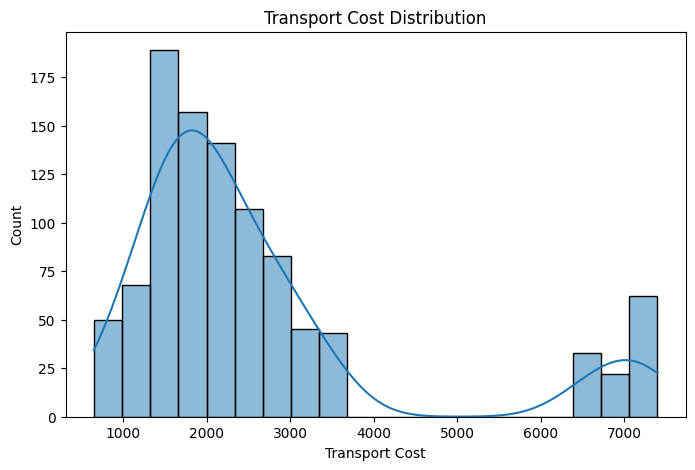

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Transport Cost"],bins=20,kde=True)
plt.title("Transport Cost Distribution")
plt.show()

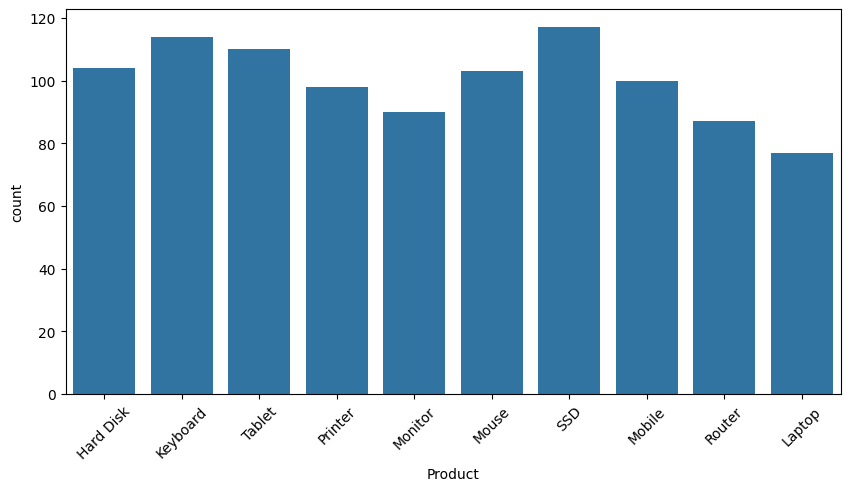

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Product")
plt.xticks(rotation=45)
plt.show()

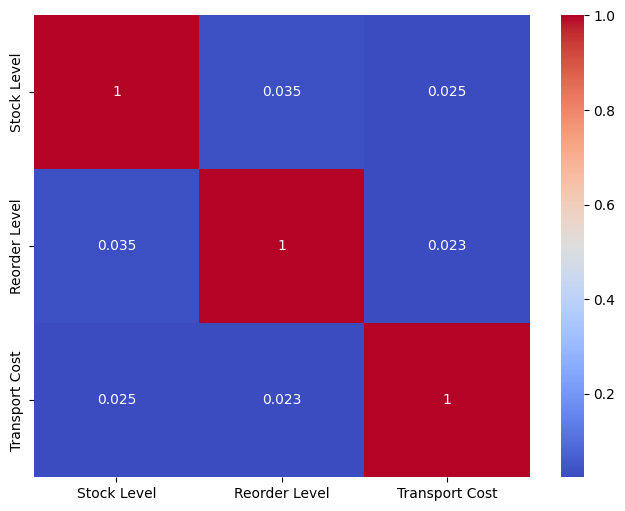

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")
plt.show()

## Phase 4 → Data Cleaning


In [16]:
df_clean= df.copy()

In [17]:
df_clean.isnull().sum()

Warehouse           0
Product             0
Stock Level       112
Reorder Level       0
Supplier            0
Last Updated        0
Transport Cost      0
dtype: int64

In [18]:
df_clean["Stock Level"] = df_clean["Stock Level"].fillna(
    df_clean["Stock Level"].median()
)

In [19]:
df_clean.head()

,Warehouse,Product,Stock Level,Reorder Level,Supplier,Last Updated,Transport Cost
0,WH-D,Hard Disk,315.0,149,Supplier-A,2026-02-01,2020
1,WH-D,Keyboard,315.0,209,Supplier-B,2024-11-17,1520
2,WH-D,Tablet,29.0,227,Supplier-Y,2025-02-23,2370
3,WH-A,Printer,464.0,92,Supplier-C,2025-05-11,2770
4,WH-C,Monitor,334.0,220,Supplier-X,2024-11-02,2800


In [20]:
df_clean.isnull().sum()

Warehouse         0
Product           0
Stock Level       0
Reorder Level     0
Supplier          0
Last Updated      0
Transport Cost    0
dtype: int64

In [21]:
df_clean["Last Updated"] = pd.to_datetime(df_clean["Last Updated"])

In [22]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Warehouse       1000 non-null   str           
 1   Product         1000 non-null   str           
 2   Stock Level     1000 non-null   float64       
 3   Reorder Level   1000 non-null   int64         
 4   Supplier        1000 non-null   str           
 5   Last Updated    1000 non-null   datetime64[us]
 6   Transport Cost  1000 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 74.6 KB


## Phase 5 → Feature Engineering


In [23]:
df_fe = df_clean.copy()

In [24]:
df_fe["Year"] = df_fe["Last Updated"].dt.year
df_fe["Month"] = df_fe["Last Updated"].dt.month
df_fe["Day"] = df_fe["Last Updated"].dt.day
df_fe["Weekday"] = df_fe["Last Updated"].dt.day_name()

In [25]:
df_fe.head()

,Warehouse,Product,Stock Level,Reorder Level,Supplier,Last Updated,Transport Cost,Year,Month,Day,Weekday
0,WH-D,Hard Disk,315.0,149,Supplier-A,2026-02-01,2020,2026,2,1,Sunday
1,WH-D,Keyboard,315.0,209,Supplier-B,2024-11-17,1520,2024,11,17,Sunday
2,WH-D,Tablet,29.0,227,Supplier-Y,2025-02-23,2370,2025,2,23,Sunday
3,WH-A,Printer,464.0,92,Supplier-C,2025-05-11,2770,2025,5,11,Sunday
4,WH-C,Monitor,334.0,220,Supplier-X,2024-11-02,2800,2024,11,2,Saturday


In [26]:
# Target variable for classification
df_fe["Stock Shortage Risk"] = (
    df_fe["Stock Level"] < df_fe["Reorder Level"]
).astype(int)

In [27]:
df_fe[["Stock Level","Reorder Level","Stock Shortage Risk"]].head(10)

,Stock Level,Reorder Level,Stock Shortage Risk
0,315.0,149,0
1,315.0,209,0
2,29.0,227,1
3,464.0,92,0
4,334.0,220,0
5,284.0,87,0
6,530.0,112,0
7,445.0,173,0
8,373.0,182,0
9,515.0,97,0


In [28]:
df_fe["Stock Shortage Risk"].value_counts()

Stock Shortage Risk
0    756
1    244
Name: count, dtype: int64

In [29]:
df_fe["Stock Shortage Risk"].value_counts(normalize=True)*100

Stock Shortage Risk
0    75.6
1    24.4
Name: proportion, dtype: float64

## Data Preprocessing (Splitting & Encoding)


In [30]:
categorical_columns = ['Warehouse', 'Product', 'Supplier', 'Weekday']

# One-hot encoding
df_encoded = pd.get_dummies(df_fe, columns=categorical_columns, drop_first=True, dtype=int)


In [31]:
df_encoded.head()

,Stock Level,Reorder Level,Last Updated,Transport Cost,Year,Month,Day,Stock Shortage Risk,Warehouse_WH-B,Warehouse_WH-C,...,Supplier_Supplier-C,Supplier_Supplier-X,Supplier_Supplier-Y,Supplier_Supplier-Z,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday
0,315.0,149,2026-02-01,2020,2026,2,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,315.0,209,2024-11-17,1520,2024,11,17,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,29.0,227,2025-02-23,2370,2025,2,23,1,0,0,...,0,0,1,0,0,0,1,0,0,0
3,464.0,92,2025-05-11,2770,2025,5,11,0,0,0,...,1,0,0,0,0,0,1,0,0,0
4,334.0,220,2024-11-02,2800,2024,11,2,0,0,1,...,0,1,0,0,0,1,0,0,0,0


In [32]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Stock Level          1000 non-null   float64       
 1   Reorder Level        1000 non-null   int64         
 2   Last Updated         1000 non-null   datetime64[us]
 3   Transport Cost       1000 non-null   int64         
 4   Year                 1000 non-null   int32         
 5   Month                1000 non-null   int32         
 6   Day                  1000 non-null   int32         
 7   Stock Shortage Risk  1000 non-null   int64         
 8   Warehouse_WH-B       1000 non-null   int64         
 9   Warehouse_WH-C       1000 non-null   int64         
 10  Warehouse_WH-D       1000 non-null   int64         
 11  Warehouse_WH-E       1000 non-null   int64         
 12  Product_Keyboard     1000 non-null   int64         
 13  Product_Laptop       1000 non-null   int64   

In [33]:
# Separate features and targets
X = df_encoded.select_dtypes(include=[np.number]).drop(['Transport Cost', 'Stock Shortage Risk'], axis=1)
y_reg = df_encoded['Transport Cost']
y_cls = df_encoded['Stock Shortage Risk']

all_cols = df_encoded.columns

In [34]:
# Train-test splits
X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42
)

In [35]:
# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['Stock Level', 'Reorder Level', 'Year', 'Month', 'Day']

In [36]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])


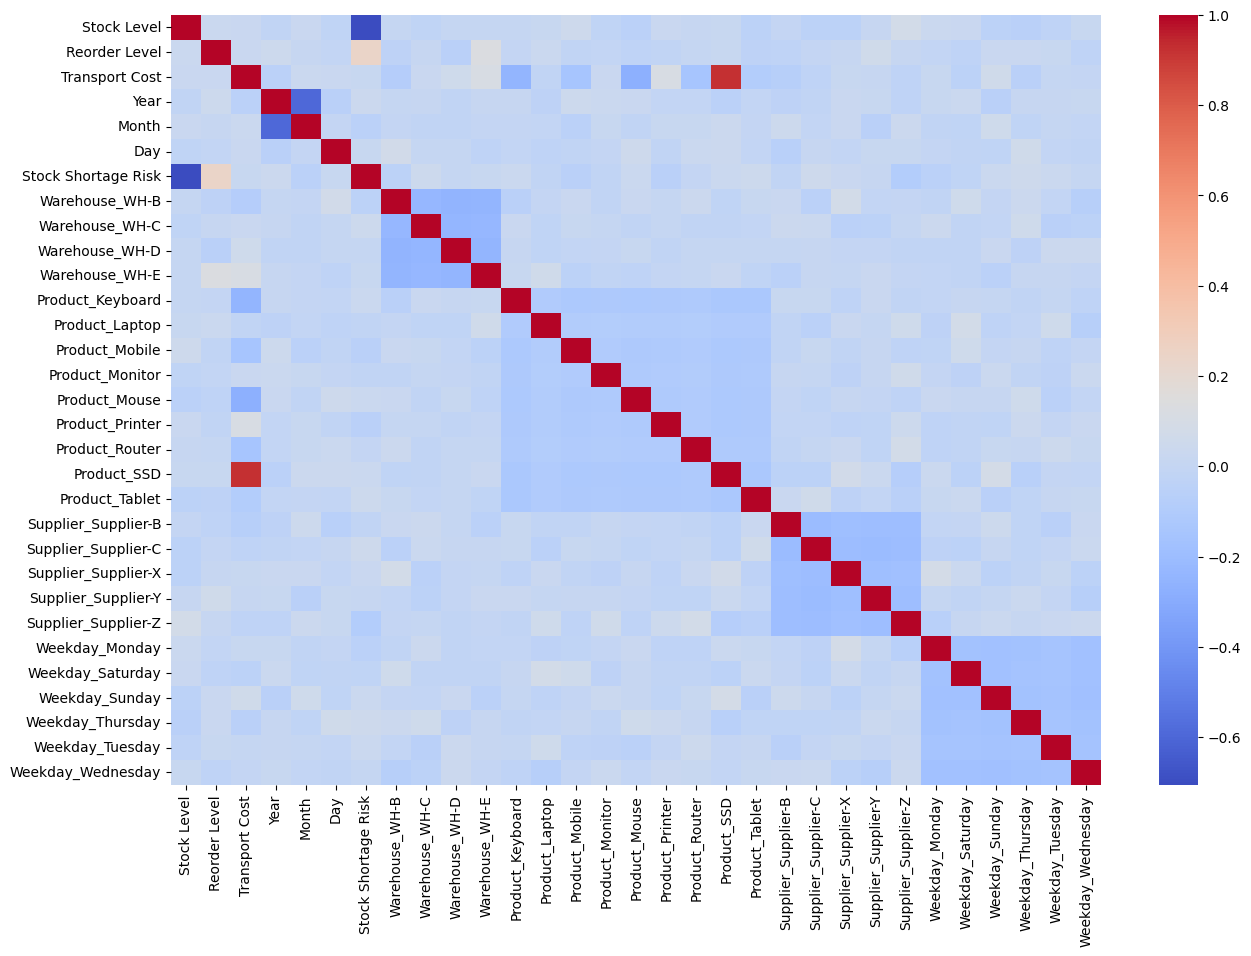

In [37]:
plt.figure(figsize=(15,10))
sns.heatmap(df_encoded.corr(numeric_only=True),cmap="coolwarm")
plt.show()

In [38]:
df_encoded.head()
df_encoded = df_encoded.drop("Last Updated", axis=1)

## Machine Learning


##  Phase 7 → Regression Model: Transport Cost

In [39]:
print('--- Linear Regression Model (Predicting Transport Cost) ---')
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train_reg)

y_pred_reg = reg_model.predict(X_test_scaled)

--- Linear Regression Model (Predicting Transport Cost) ---


### Classification : Stock Shortage Risk

In [40]:
print('--- Random Forest Classification Model (Predicting Stock Shortage Risk) ---')
cls_model = RandomForestClassifier(random_state=42, n_estimators=100)
cls_model.fit(X_train_scaled, y_train_cls)

y_pred_cls = cls_model.predict(X_test_scaled)
y_prob_cls = cls_model.predict_proba(X_test_scaled)[:, 1]

--- Random Forest Classification Model (Predicting Stock Shortage Risk) ---


## Phase 9 → Model Evaluation


### 1 Linear Regression

In [41]:
lr=LinearRegression()
lr.fit(
  X_train_scaled,y_train_reg
)
y_prediction_reg=lr.predict(X_test_scaled)
print(y_prediction_reg)

[1550. 1450. 1450. 1850. 1650. 1500. 2370. 2200. 2650.  950. 1800. 1800.
 2400.  900. 1870. 1500. 1650. 1800. 3120. 1050. 2800. 2000. 7050. 1900.
 1150. 2450. 1950. 7220. 1750. 2950. 2070. 3070. 1370. 1150. 1100. 1650.
 1100. 7100. 1950. 1300. 1670. 1650. 7200. 1000. 2220. 2670. 2120. 1820.
 1000. 3120. 1900. 7050. 7400. 1200. 1850. 2450.  800. 2850. 2900. 2820.
 2000. 1600. 1470. 2800.  800. 1600. 1850. 1300. 3370. 1850. 1050. 3000.
 1250. 1450. 1950. 1400. 2920. 1600.  950. 2850. 2770. 7220. 3100. 6650.
 3100. 1920. 2400. 1600. 7200. 1520. 7250. 7300. 2370. 1770. 1520. 6650.
 1570. 1750. 2450. 1700. 2820. 1350. 2770. 1970. 1800. 7320. 3070. 2000.
  750. 1950. 7320. 3270. 2120. 7070. 7150. 2900. 2250. 1550. 1750.  950.
 2400. 1550. 2250. 2670.  900. 2950. 2350. 6500. 1150. 2400. 1850. 2000.
  800. 3070. 2720. 2050.  900. 1770. 3540.  950. 2000. 2500. 2920. 2850.
 1050. 1570. 2870. 7400. 1620. 2650. 1600. 1700. 1800. 1700. 1350. 2500.
 1850. 1450. 1720. 7300. 1550. 1850. 2600. 7100. 25

In [42]:
mean_absolute_error(y_test_reg,y_prediction_reg)

2.4238033802248538e-12

In [43]:
mean_squared_error(y_test_reg,y_prediction_reg)

9.338352127840837e-24

In [44]:
r2_score(y_test_reg,y_prediction_reg)

1.0

### PART B : CLASSIFICATION

### 1 RandomForestClassifier

In [45]:
log_model=RandomForestClassifier()
log_model.fit(
  X_train_scaled,
  y_train_cls
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [46]:
y_pred_cls = cls_model.predict(X_test_scaled)
print(y_pred_cls)

[0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 0
 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0]


In [47]:
print("Accuracy :", accuracy_score(y_test_cls, y_pred_cls))

print("Precision :", precision_score(y_test_cls, y_pred_cls))

print("Recall :", recall_score(y_test_cls, y_pred_cls))

print("F1 :", f1_score(y_test_cls, y_pred_cls))

print("R2 Score :", r2_score(y_test_cls,y_pred_cls))

Accuracy : 0.985
Precision : 0.9782608695652174
Recall : 0.9574468085106383
F1 : 0.967741935483871
R2 Score : 0.9165623696287025
